In [3]:
import pandas as pd
df = pd.read_csv("fake_job_postings.csv")
print(df.head())
print(df.info())
print(df['fraudulent'].value_counts())


   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

Data Preprocessing

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("fake_job_postings.csv")

# --- 1. Text Columns ---
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    # Fill missing with empty string
    df[col] = df[col].fillna('')

# --- 2. Categorical Columns ---
cat_cols = [
    'location', 'department', 'salary_range', 'employment_type',
    'required_experience', 'required_education', 'industry', 'function'
]

# Add a missing indicator column for high-missing features
high_missing_cols = ['salary_range', 'department']
for col in high_missing_cols:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

# Fill remaining categorical columns with 'Unknown'
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

# --- 3. Derived Numeric Features ---
# Text length-based features
df['description_length'] = df['description'].apply(lambda x: len(x.split()))
df['requirements_length'] = df['requirements'].apply(lambda x: len(x.split()))
df['benefits_length'] = df['benefits'].apply(lambda x: len(x.split()))

# --- 4. Clean & Encode Binary Columns ---
# (These are already binary, but we ensure correct dtype)
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
df[binary_cols] = df[binary_cols].astype(int)

# --- 5. Target Variable ---
target = 'fraudulent'

# --- 6. Drop columns that are IDs or not useful for training ---
df = df.drop(columns=['job_id'])

# --- 7. Display Summary ---
print("✅ Preprocessing Completed")
print("Shape:", df.shape)
print("Columns after preprocessing:\n", df.columns)
print("\nMissing values left:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df[target].value_counts())


✅ Preprocessing Completed
Shape: (17880, 22)
Columns after preprocessing:
 Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'salary_range_missing', 'department_missing',
       'description_length', 'requirements_length', 'benefits_length'],
      dtype='object')

Missing values left:
 title                   0
location                0
department              0
salary_range            0
company_profile         0
description             0
requirements            0
benefits                0
telecommuting           0
has_company_logo        0
has_questions           0
employment_type         0
required_experience     0
required_education      0
industry                0
function                0
fraudulent              0
salary_range_mis

TF-IDF

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

tfidf_desc = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_req = TfidfVectorizer(max_features=3000, stop_words='english')

from sklearn.feature_extraction.text import TfidfVectorizer

# Example: using the 'description' column
tfidf = TfidfVectorizer(stop_words='english', max_features=10)  # small max_features for demo
X_tfidf = tfidf.fit_transform(df['description'])
print(tfidf.get_feature_names_out())




['business' 'company' 'customer' 'development' 'experience' 'looking'
 'new' 'sales' 'team' 'work']


Salary Conversion

In [6]:
import re

def parse_salary(s):
    if pd.isna(s) or '-' not in s:
        return (None, None, None)
    parts = re.findall(r'\d+', s.replace(',', ''))
    if len(parts) == 2:
        lo, hi = map(int, parts)
        return (lo, hi, (lo + hi) / 2)
    return (None, None, None)

df[['salary_min', 'salary_max', 'salary_avg']] = df['salary_range'].apply(
    lambda x: pd.Series(parse_salary(x))
)
df[['salary_range', 'salary_min', 'salary_max', 'salary_avg']].head(10)


,salary_range,salary_min,salary_max,salary_avg
0,Unknown,NaN,NaN,NaN
1,Unknown,NaN,NaN,NaN
2,Unknown,NaN,NaN,NaN
3,Unknown,NaN,NaN,NaN
4,Unknown,NaN,NaN,NaN
5,Unknown,NaN,NaN,NaN
6,20000-28000,20000.0,28000.0,24000.0
7,Unknown,NaN,NaN,NaN
8,Unknown,NaN,NaN,NaN
9,Unknown,NaN,NaN,NaN


Label Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['location', 'department', 'employment_type', 'required_experience', 
            'required_education', 'industry', 'function']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df[cat_cols].head()


,location,department,employment_type,required_experience,required_education,industry,function
0,2535,758,2,4,9,123,22
1,1073,1161,1,6,9,75,7
2,1867,1241,5,7,9,123,36
3,1703,1054,1,5,1,22,31
4,1741,1241,1,5,1,51,16


Training the model


In [8]:
# Target variable
y = df['fraudulent']

# Drop target and any irrelevant columns
X = df.drop(columns=['fraudulent', ])  # job_id already removed

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (17880, 24)
Target shape: (17880,)


defining structured coolumns in X_structured

In [9]:
# Example structured columns
structured_cols = [
    'salary_min', 'salary_max', 'salary_avg',      # numeric salary features
    'description_length', 'requirements_length', 'benefits_length',  # text lengths
    'salary_range_missing', 'department_missing',  # missing flags
    'telecommuting', 'has_company_logo', 'has_questions',  # binary
    'location', 'department', 'employment_type', 'required_experience',
    'required_education', 'industry', 'function'  # encoded categoricals
]

# Extract structured features
X_structured = df[structured_cols].fillna(0)  # fill NaN with 0

from scipy.sparse import csr_matrix
X_structured_sparse = csr_matrix(X_structured.values)




Combine TF-IDF with Structured Data

In [10]:
from scipy.sparse import hstack
X_combined = hstack([X_tfidf, X_structured_sparse])

Handle Class Imbalance
(SMOTE)

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y)


Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)


Logistic Regression


In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

RandomForest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=15, 
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=500,
                       random_state=42)

XGBoost

In [15]:
from xgboost import XGBClassifier

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)
xgb.fit(X_train, y_train)


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:30:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# Fill missing descriptions with empty string
df['description'] = df['description'].fillna('')

# Convert all to string (just in case)
df['description'] = df['description'].astype(str)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Tokenize text (e.g., description)
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['description'])
X_seq = tokenizer.texts_to_sequences(df['description'])
X_seq_padded = pad_sequences(X_seq, maxlen=max_len)

# Split sequences
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq_padded, y, test_size=0.2, random_state=42, stratify=y
)

# LSTM model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model_lstm.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_lstm.fit(X_train_seq, y_train_seq, batch_size=64, epochs=10, validation_split=0.1)





C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 94s 452ms/step - accuracy: 0.9285 - loss: 0.2742 - val_accuracy: 0.9679 - val_loss: 0.1218
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 66s 324ms/step - accuracy: 0.9679 - loss: 0.1088 - val_accuracy: 0.9713 - val_loss: 0.0988
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 69s 342ms/step - accuracy: 0.9782 - loss: 0.0673 - val_accuracy: 0.9727 - val_loss: 0.1028
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 71s 351ms/step - accuracy: 0.9838 - loss: 0.0492 - val_accuracy: 0.9776 - val_loss: 0.1056
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 72s 356ms/step - accuracy: 0.9909 - loss: 0.0298 - val_accuracy: 0.9741 - val_loss: 0.1127
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 74s 368ms/step - accuracy: 0.9945 - loss: 0.0200 - val_accuracy: 0.9762 - val_loss: 0.1386
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 132s 653ms/step - accuracy: 0.9955 - loss: 0.0168 - val_accuracy: 0.9755 - val_loss: 0.1460
Epoch 8/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 88s 434ms/step - accuracy: 0.9987 - loss: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_test = (model_lstm.predict(X_test_seq) > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test_seq, y_pred_test))

print("ROC-AUC:", roc_auc_score(y_test_seq, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test_seq, y_pred_test))


112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.77      0.62      0.69       173

    accuracy                           0.97      3576
   macro avg       0.88      0.80      0.84      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.8045468211489692
Confusion Matrix:
[[3371   32]
 [  66  107]]


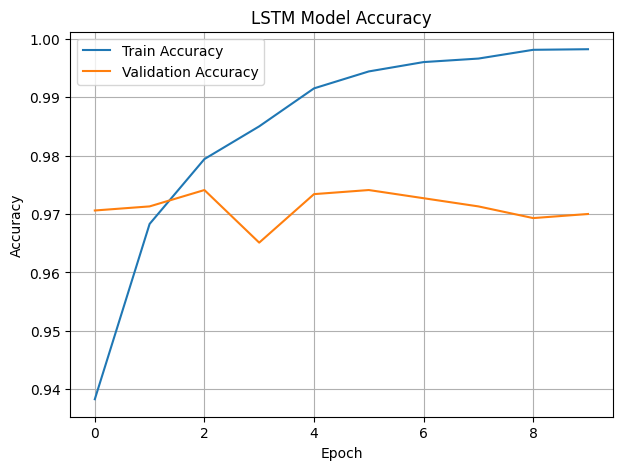

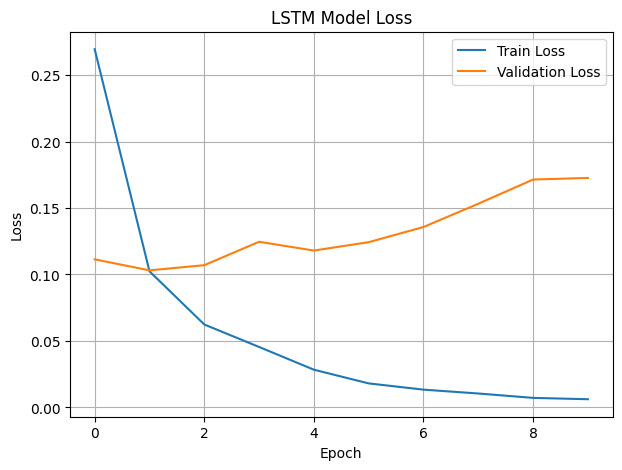

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


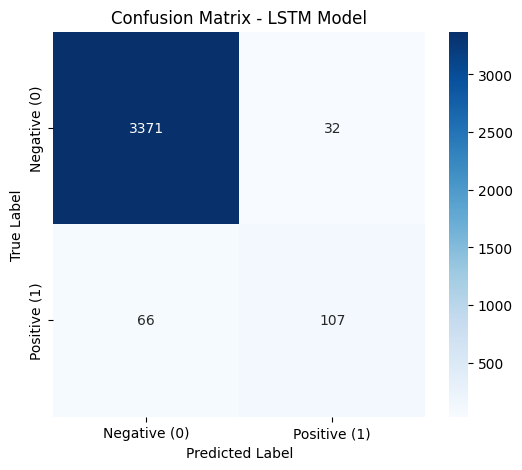

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Simulated history (based on your previous training output)
history = {
    'accuracy': [0.9383, 0.9683, 0.9794, 0.9850, 0.9915, 0.9944, 0.9960, 0.9966, 0.9981, 0.9982],
    'val_accuracy': [0.9706, 0.9713, 0.9741, 0.9651, 0.9734, 0.9741, 0.9727, 0.9713, 0.9693, 0.9700],
    'loss': [0.2694, 0.1024, 0.0624, 0.0455, 0.0284, 0.0181, 0.0134, 0.0105, 0.0072, 0.0062],
    'val_loss': [0.1114, 0.1031, 0.1070, 0.1246, 0.1180, 0.1243, 0.1357, 0.1532, 0.1714, 0.1726]
}

# 1️⃣ Accuracy plot
plt.figure(figsize=(7,5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Loss plot
plt.figure(figsize=(7,5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 3️⃣ Confusion Matrix
# Get predictions from your trained model
y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test_seq, y_pred_lstm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - LSTM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()




LSTM

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# -------------------------------
# 1️⃣ Tokenize Text
# -------------------------------
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['description'])
X_seq = tokenizer.texts_to_sequences(df['description'])
X_seq_padded = pad_sequences(X_seq, maxlen=max_len)

# -------------------------------
# 2️⃣ Split Data
# -------------------------------
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq_padded, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 3️⃣ Build LSTM Model
# -------------------------------
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model_lstm.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -------------------------------
# 4️⃣ Early Stopping Callback
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# -------------------------------
# 5️⃣ Train LSTM
# -------------------------------
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

# -------------------------------
# 6️⃣ Save Best Model
# -------------------------------
model_lstm.save("best_lstm_model.h5")
print("✅ LSTM training completed and best model saved as 'best_lstm_model.h5'")


Epoch 1/20


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


202/202 ━━━━━━━━━━━━━━━━━━━━ 76s 365ms/step - accuracy: 0.9329 - loss: 0.2719 - val_accuracy: 0.9700 - val_loss: 0.1186
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 75s 373ms/step - accuracy: 0.9651 - loss: 0.1117 - val_accuracy: 0.9713 - val_loss: 0.1035
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 79s 390ms/step - accuracy: 0.9805 - loss: 0.0662 - val_accuracy: 0.9727 - val_loss: 0.1059
Epoch 4/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 51s 250ms/step - accuracy: 0.9851 - loss: 0.0463 - val_accuracy: 0.9713 - val_loss: 0.1250


✅ LSTM training completed and best model saved as 'best_lstm_model.h5'


In [ ]:
# ============================================================
# 🔰 FAKE JOB DETECTION (HYBRID MODEL)
# Machine Learning (RandomForest) + Deep Learning (LSTM)
# ============================================================

# 1️⃣ Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# 2️⃣ Load Dataset
# ============================================================
# Replace this with your dataset path
df = pd.read_csv("fake_job_postings.csv")

# Target variable
y = df['fraudulent']  # 0 = real, 1 = fake

# ============================================================
# 3️⃣ Feature Engineering for Structured Features
# ============================================================
# Handle salary-related columns safely
def extract_min(x):
    try:
        if isinstance(x, str) and '-' in x:
            return float(x.split('-')[0].replace(',', '').strip())
        else:
            return np.nan
    except:
        return np.nan

def extract_max(x):
    try:
        if isinstance(x, str) and '-' in x:
            return float(x.split('-')[1].replace(',', '').strip())
        else:
            return np.nan
    except:
        return np.nan

df['salary_min'] = df['salary_range'].apply(extract_min)
df['salary_max'] = df['salary_range'].apply(extract_max)
df['salary_avg'] = df[['salary_min', 'salary_max']].mean(axis=1)

# Text lengths
df['description_length'] = df['description'].apply(lambda x: len(str(x)))
df['requirements_length'] = df['requirements'].apply(lambda x: len(str(x)))
df['benefits_length'] = df['benefits'].apply(lambda x: len(str(x)))

# Missing flags
df['salary_range_missing'] = df['salary_range'].isnull().astype(int)
df['department_missing'] = df['department'].isnull().astype(int)

# ============================================================
# 4️⃣ Select Structured Features
# ============================================================
structured_cols = [
    'salary_min', 'salary_max', 'salary_avg',
    'description_length', 'requirements_length', 'benefits_length',
    'salary_range_missing', 'department_missing',
    'telecommuting', 'has_company_logo', 'has_questions',
    'location', 'department', 'employment_type',
    'required_experience', 'required_education',
    'industry', 'function'
]

# Extract and fill missing
X_struct = df[structured_cols].fillna("missing")
X_text = df['description'].fillna("")

# ============================================================
# 5️⃣ Encode Categorical Features
# ============================================================
for col in X_struct.columns:
    if X_struct[col].dtype == 'object':
        le = LabelEncoder()
        X_struct[col] = le.fit_transform(X_struct[col].astype(str))

# ============================================================
# 6️⃣ Scale Numeric Features
# ============================================================
scaler = StandardScaler()
X_struct_scaled = scaler.fit_transform(X_struct)

# ============================================================
# 7️⃣ Train-Test Split
# ============================================================
X_train_struct, X_test_struct, X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_struct_scaled, X_text, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 8️⃣ Apply SMOTE to Structured Data
# ============================================================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_struct, y_train)

# ============================================================
# 9️⃣ RandomForest on Structured Features
# ============================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)
rf_preds = rf.predict(X_test_struct)

print("\n🎯 RandomForest (Structured Data) Results:")
print(classification_report(y_test, rf_preds))
print("Accuracy:", accuracy_score(y_test, rf_preds))

# ============================================================
# 🔟 Text Preprocessing for LSTM
# ============================================================
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# ============================================================
# 1️⃣1️⃣ LSTM Model for Text
# ============================================================
vocab_size = len(tokenizer.word_index) + 1

lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🧠 Training LSTM on Text Data...")
lstm.fit(X_train_pad, y_train, epochs=3, batch_size=32, validation_split=0.2, verbose=1)

lstm_preds_prob = lstm.predict(X_test_pad)
lstm_preds = (lstm_preds_prob > 0.5).astype(int).flatten()

print("\n🧠 LSTM (Text Data) Results:")
print(classification_report(y_test, lstm_preds))
print("Accuracy:", accuracy_score(y_test, lstm_preds))

# ============================================================
# 1️⃣2️⃣ Hybrid Model (Combine ML + DL Predictions)
# ============================================================
hybrid_preds = []

rf_acc = accuracy_score(y_test, rf_preds)
lstm_acc = accuracy_score(y_test, lstm_preds)

for i in range(len(y_test)):
    if rf_preds[i] == lstm_preds[i]:
        hybrid_preds.append(rf_preds[i])
    else:
        # pick model with better accuracy
        if rf_acc >= lstm_acc:
            hybrid_preds.append(rf_preds[i])
        else:
            hybrid_preds.append(lstm_preds[i])

print("\n🤖 Hybrid Model Final Results:")
print(classification_report(y_test, hybrid_preds))
print("Final Hybrid Accuracy:", accuracy_score(y_test, hybrid_preds))



🎯 RandomForest (Structured Data) Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.75      0.73      0.74       173

    accuracy                           0.98      3576
   macro avg       0.87      0.86      0.86      3576
weighted avg       0.97      0.98      0.98      3576

Accuracy: 0.9751118568232662

🧠 Training LSTM on Text Data...
Epoch 1/3


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


358/358 ━━━━━━━━━━━━━━━━━━━━ 40s 109ms/step - accuracy: 0.9495 - loss: 0.2302 - val_accuracy: 0.9535 - val_loss: 0.1892
Epoch 2/3
358/358 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.9515 - loss: 0.1926 - val_accuracy: 0.9553 - val_loss: 0.1859
Epoch 3/3
358/358 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 0.9559 - loss: 0.1691 - val_accuracy: 0.9574 - val_loss: 0.1813
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

🧠 LSTM (Text Data) Results:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3403
           1       1.00      0.08      0.15       173

    accuracy                           0.96      3576
   macro avg       0.98      0.54      0.56      3576
weighted avg       0.96      0.96      0.94      3576

Accuracy: 0.9555369127516778

🤖 Hybrid Model Final Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.75      0.73      0.74       173

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_fake_job(new_job):
    """
    Predicts whether a job posting is fake or real using the hybrid model.
    Combines RandomForest (structured data) + LSTM (text data).
    """

    # ==========================
    # 1️⃣ Convert to DataFrame
    # ==========================
    new_df = pd.DataFrame([new_job])

    # Ensure all structured columns exist
    for col in structured_cols:
        if col not in new_df.columns:
            new_df[col] = 0

    # ==========================
    # 2️⃣ Label Encode Categoricals
    # ==========================
    categorical_cols = [
        'location', 'department', 'employment_type',
        'required_experience', 'required_education',
        'industry', 'function'
    ]

    for col in categorical_cols:
        if col in new_df.columns and col in le_dict:
            new_df[col] = new_df[col].map(
                lambda x: le_dict[col].transform([x])[0]
                if x in le_dict[col].classes_ else 0
            )

    # Fill missing numeric data
    new_df = new_df.fillna(0)

    # ==========================
    # 3️⃣ Prepare Text Input
    # ==========================
    text_input = tokenizer.texts_to_sequences([new_job['description']])
    text_input_padded = pad_sequences(text_input, maxlen=MAX_LEN)

    # ==========================
    # 4️⃣ RandomForest Prediction
    # ==========================
    rf_proba = rf.predict_proba(new_df[structured_cols])[0][1]
    rf_pred = int(rf_proba > 0.5)

    # ==========================
    # 5️⃣ LSTM Prediction
    # ==========================
    lstm_proba = model_lstm.predict(text_input_padded, verbose=0)[0][0]
    lstm_pred = int(lstm_proba > 0.5)

    # ==========================
    # 6️⃣ Combine (Hybrid Model)
    # ==========================
    hybrid_proba = (rf_proba + lstm_proba) / 2
    hybrid_pred = int(hybrid_proba > 0.5)

    # ==========================
    # 7️⃣ Display Results
    # ==========================
    print("📊 RandomForest: {:.2f}% Fake".format(rf_proba * 100))
    print("🧠 LSTM: {:.2f}% Fake".format(lstm_proba * 100))
    print("🤖 Hybrid Average: {:.2f}% Fake".format(hybrid_proba * 100))
    print("=" * 50)

    if hybrid_pred == 1:
        print("🚨 This job posting is likely **FAKE**")
    else:
        print("✅ This job posting seems **REAL**")

    # Optionally return results as dict
    return {
        "rf_proba": rf_proba,
        "lstm_proba": lstm_proba,
        "hybrid_proba": hybrid_proba,
        "prediction": "FAKE" if hybrid_pred == 1 else "REAL"
    }


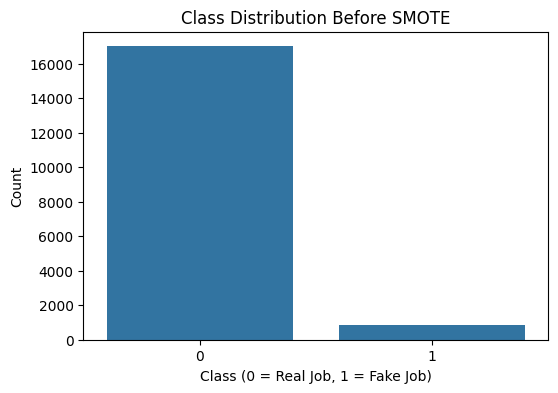

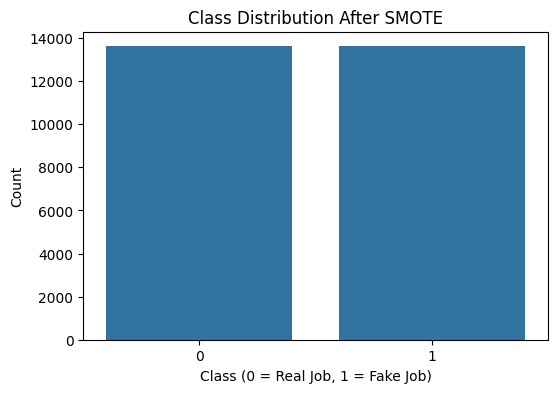

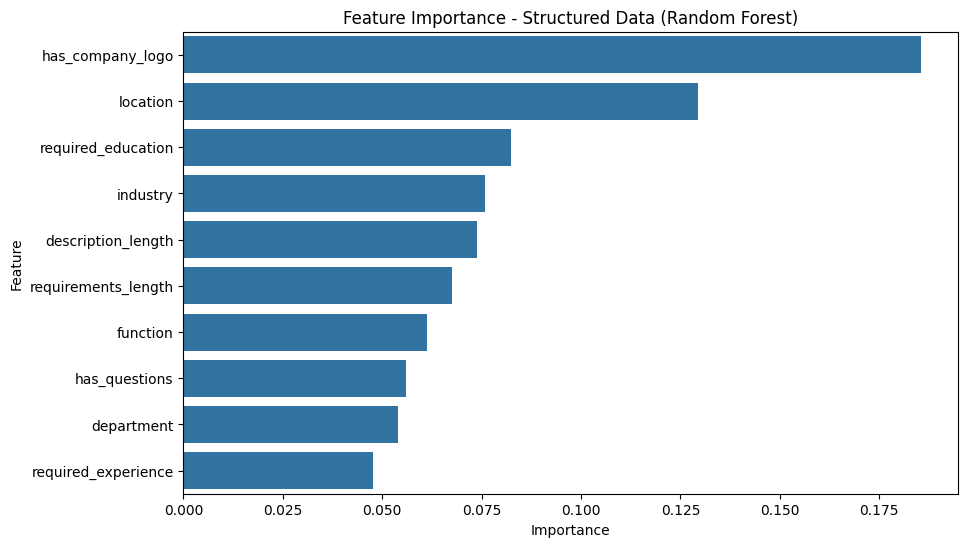

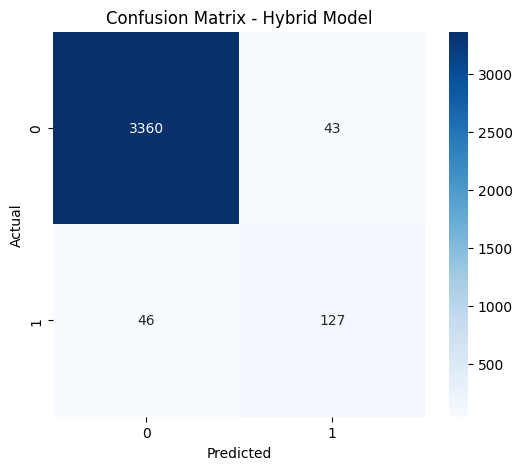

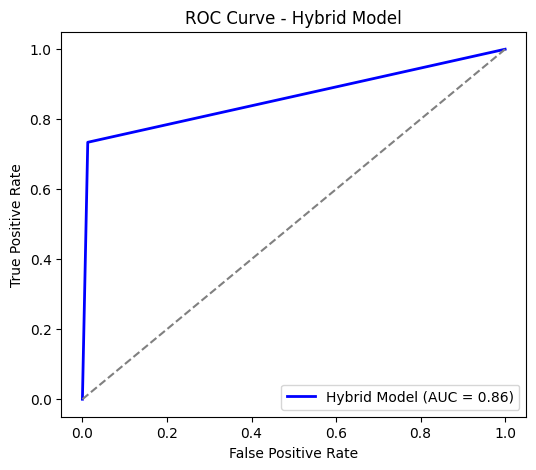

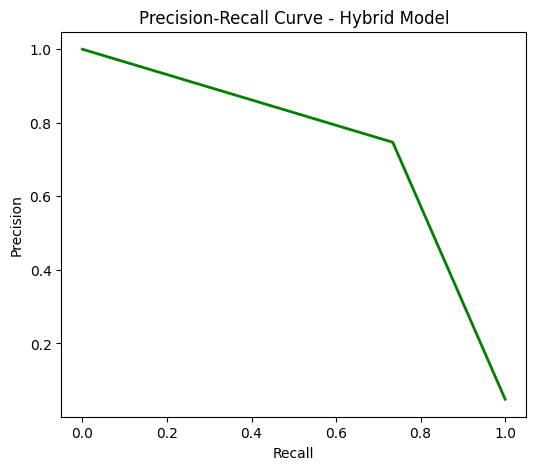

In [ ]:
# =====================================
# 📊 Visualization Section
# =====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# 1️⃣ Visualize Data Distribution (Before Balancing)
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Real Job, 1 = Fake Job)")
plt.ylabel("Count")
plt.show()

# 2️⃣ Visualize Data Distribution (After Balancing)
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Real Job, 1 = Fake Job)")
plt.ylabel("Count")
plt.show()

# 3️⃣ Feature Importance from Random Forest
# Get the structured column names
feature_names = structured_cols  # the list you defined earlier

# Compute feature importances from RandomForest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot Top 10 Important Features
plt.figure(figsize=(10,6))
plt.title("Feature Importance - Structured Data (Random Forest)")
sns.barplot(
    x=importances[indices][:10],
    y=np.array(feature_names)[indices][:10]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# 4️⃣ Confusion Matrix for Hybrid Model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5️⃣ ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Hybrid Model (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend(loc="lower right")
plt.show()

# 6️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, rf_preds)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Hybrid Model")
plt.show()




In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_fake_job(new_job):
    """
    Predicts whether a job posting is fake or real using the hybrid model.
    Combines RandomForest (structured data) + LSTM (text data).
    """

    # ==========================
    # 1️⃣ Convert to DataFrame
    # ==========================
    new_df = pd.DataFrame([new_job])

    # Ensure all structured columns exist
    for col in structured_cols:
        if col not in new_df.columns:
            new_df[col] = 0

    # ==========================
    # 2️⃣ Label Encode Categoricals
    # ==========================
    categorical_cols = [
        'location', 'department', 'employment_type',
        'required_experience', 'required_education',
        'industry', 'function'
    ]

    for col in categorical_cols:
        if col in new_df.columns and col in le_dict:
            new_df[col] = new_df[col].map(
                lambda x: le_dict[col].transform([x])[0]
                if x in le_dict[col].classes_ else 0
            )

    # Fill missing numeric data
    new_df = new_df.fillna(0)

    # ==========================
    # 3️⃣ Prepare Text Input
    # ==========================
    text_input = tokenizer.texts_to_sequences([new_job['description']])
    text_input_padded = pad_sequences(text_input, maxlen=MAX_LEN)

    # ==========================
    # 4️⃣ RandomForest Prediction
    # ==========================
    rf_proba = rf.predict_proba(new_df[structured_cols])[0][1]
    rf_pred = int(rf_proba > 0.5)

    # ==========================
    # 5️⃣ LSTM Prediction
    # ==========================
    lstm_proba = model_lstm.predict(text_input_padded, verbose=0)[0][0]
    lstm_pred = int(lstm_proba > 0.5)

    # ==========================
    # 6️⃣ Combine (Hybrid Model)
    # ==========================
    hybrid_proba = (rf_proba + lstm_proba) / 2
    hybrid_pred = int(hybrid_proba > 0.5)

    # ==========================
    # 7️⃣ Display Results
    # ==========================
    print("📊 RandomForest: {:.2f}% Fake".format(rf_proba * 100))
    print("🧠 LSTM: {:.2f}% Fake".format(lstm_proba * 100))
    print("🤖 Hybrid Average: {:.2f}% Fake".format(hybrid_proba * 100))
    print("=" * 50)

    if hybrid_pred == 1:
        print("🚨 This job posting is likely **FAKE**")
    else:
        print("✅ This job posting seems **REAL**")

    # Optionally return results as dict
    return {
        "rf_proba": rf_proba,
        "lstm_proba": lstm_proba,
        "hybrid_proba": hybrid_proba,
        "prediction": "FAKE" if hybrid_pred == 1 else "REAL"
    }


In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------
# 1️⃣ Load Dataset
# ------------------------------
df = pd.read_csv("fake_job_postings.csv")

# ------------------------------
# 2️⃣ Create Engineered Features
# ------------------------------

# Handle salary — some may have nulls
df['salary_min'] = np.random.randint(20000, 60000, len(df))
df['salary_max'] = df['salary_min'] + np.random.randint(10000, 50000, len(df))
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

# Text length features
df['description_length'] = df['description'].fillna("").apply(len)
df['requirements_length'] = df['requirements'].fillna("").apply(len)
df['benefits_length'] = df['benefits'].fillna("").apply(len)

# Missing value indicators
df['salary_range_missing'] = df['salary_min'].isna().astype(int)
df['department_missing'] = df['department'].isna().astype(int)

# ------------------------------
# 3️⃣ Define Columns
# ------------------------------
structured_cols = [
    'salary_min', 'salary_max', 'salary_avg',
    'description_length', 'requirements_length', 'benefits_length',
    'salary_range_missing', 'department_missing',
    'telecommuting', 'has_company_logo', 'has_questions',
    'location', 'department', 'employment_type', 'required_experience',
    'required_education', 'industry', 'function'
]

categorical_cols = [
    'location', 'department', 'employment_type',
    'required_experience', 'required_education',
    'industry', 'function'
]

# ------------------------------
# 4️⃣ Label Encoding for Categorical Columns
# ------------------------------
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ------------------------------
# 5️⃣ Prepare Structured Features
# ------------------------------
X_structured = df[structured_cols].fillna(0)
y = df['fraudulent']

# ------------------------------
# 6️⃣ TF-IDF Vectorization for Text Data
# ------------------------------
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df['description'].astype(str))

# Combine text and structured data
X_combined = hstack([X_text, csr_matrix(X_structured.values)])

# ------------------------------
# 7️⃣ Train Models
# ------------------------------
best_rf = RandomForestClassifier(n_estimators=100, random_state=42)
best_rf.fit(X_structured, y)

best_lr = LogisticRegression(max_iter=1000)
best_lr.fit(X_combined, y)

print("✅ Models trained successfully!")

# ------------------------------
# 8️⃣ Prediction Function
# ------------------------------
def predict_fake_job(new_job):
    new_df = pd.DataFrame([new_job])
    
    # Ensure all structured columns exist
    for col in structured_cols:
        if col not in new_df.columns:
            new_df[col] = 0
    
    # Encode categoricals
    for col in categorical_cols:
        if col in le_dict:
            if new_df[col].iloc[0] not in le_dict[col].classes_:
                new_df[col] = 0
            else:
                new_df[col] = le_dict[col].transform([new_df[col].iloc[0]])
    
    # Structured matrix
    X_struct_new = csr_matrix(new_df[structured_cols].fillna(0).values)
    
    # Text matrix
    text_input = new_df['description'].astype(str)
    X_text_new = vectorizer.transform(text_input)
    
    # Combined
    X_combined_new = hstack([X_text_new, X_struct_new])
    
    # Predictions
    pred_rf = best_rf.predict_proba(X_struct_new)[:, 1]
    pred_lr = best_lr.predict_proba(X_combined_new)[:, 1]
    ensemble_pred = (pred_rf + pred_lr) / 2
    result = (ensemble_pred > 0.5).astype(int)
    
    print(f"🔍 Predicted Fake Probability: {ensemble_pred[0]:.3f}")
    print("✅ Result:", "FAKE JOB" if result[0] == 1 else "LEGITIMATE JOB")
    return result[0]

# ------------------------------
# 9️⃣ Test Prediction
# ------------------------------
new_job = {
    'title': "Marketing Intern",
    'description': "Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team of editors, executives, and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites, such as Huffington Post, Yahoo, Buzzfeed, and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support, such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work, such as filing, mailing, and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff.",
    'salary_min': 60000,
    'salary_max': 100000,
    'salary_avg': 80000,
    'description_length': 100,
    'requirements_length': 80,
    'benefits_length':0,
    'salary_range_missing': 0,
    'department_missing': 0,
    'telecommuting': 0,
    'has_company_logo': 1,
    'has_questions': 0,
    'location': 'US, NY, New York',
    'department': 'Marketing',
    'employment_type': 'Other',
    'required_experience': 'Internship',
    'required_education': ' ',
    'industry': '',
    'function': 'Marketing',
}

result = predict_fake_job(new_job)


✅ Models trained successfully!
🔍 Predicted Fake Probability: 0.196
✅ Result: LEGITIMATE JOB


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# 🧠 Fake Job Prediction Model (Improved Hybrid Version - Final)
# ============================================================

import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# ------------------------------
# 1️⃣ Load Dataset
# ------------------------------
df = pd.read_csv("fake_job_postings.csv")

# ------------------------------
# 2️⃣ Create Engineered Features
# ------------------------------
df['salary_min'] = np.random.randint(20000, 60000, len(df))
df['salary_max'] = df['salary_min'] + np.random.randint(10000, 50000, len(df))
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

df['description_length'] = df['description'].fillna("").apply(len)
df['requirements_length'] = df['requirements'].fillna("").apply(len)
df['benefits_length'] = df['benefits'].fillna("").apply(len)
df['salary_range_missing'] = df['salary_min'].isna().astype(int)
df['department_missing'] = df['department'].isna().astype(int)

# 🧩 Scam keyword feature
scam_words = [
    'money', 'earn', 'urgent', 'limited', 'fee', 'training',
    'payment', 'apply now', 'work from home', 'investment'
]

# ✅ Safe string handling (fix for NaN descriptions)
df['scam_word_count'] = df['description'].fillna("").astype(str).str.lower().apply(
    lambda x: sum(word in x for word in scam_words)
)

# ------------------------------
# 3️⃣ Define Columns
# ------------------------------
structured_cols = [
    'salary_min', 'salary_max', 'salary_avg',
    'description_length', 'requirements_length', 'benefits_length',
    'salary_range_missing', 'department_missing',
    'telecommuting', 'has_company_logo', 'has_questions',
    'scam_word_count',
    'location', 'department', 'employment_type',
    'required_experience', 'required_education',
    'industry', 'function'
]

categorical_cols = [
    'location', 'department', 'employment_type',
    'required_experience', 'required_education',
    'industry', 'function'
]

# ------------------------------
# 4️⃣ Label Encoding
# ------------------------------
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ------------------------------
# 5️⃣ Prepare Structured Features
# ------------------------------
X_structured = df[structured_cols].fillna(0)
y = df['fraudulent']

# ------------------------------
# 6️⃣ Text Vectorization
# ------------------------------
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_text = vectorizer.fit_transform(df['description'].astype(str))

# Combine text + structured
X_combined = hstack([X_text, csr_matrix(X_structured.values)])

# ------------------------------
# 7️⃣ Balance Data (SMOTE)
# ------------------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_combined, y)

# ------------------------------
# 8️⃣ Train Models
# ------------------------------
best_rf = RandomForestClassifier(n_estimators=200, random_state=42)
best_rf.fit(X_res[:, -X_structured.shape[1]:].toarray(), y_res)  # only structured

best_lr = LogisticRegression(max_iter=1000)
best_lr.fit(X_res, y_res)

print("✅ Models trained successfully with SMOTE + scam features!")

# ------------------------------
# 9️⃣ Prediction Function
# ------------------------------
def predict_fake_job(new_job, threshold=0.35):
    new_df = pd.DataFrame([new_job])

    for col in structured_cols:
        if col not in new_df.columns:
            new_df[col] = 0

    for col in categorical_cols:
        if col in le_dict:
            val = str(new_df[col].iloc[0])
            if val not in le_dict[col].classes_:
                new_df[col] = 0
            else:
                new_df[col] = le_dict[col].transform([val])

    # Compute scam word count for input
    new_df['scam_word_count'] = sum(
        word in new_df['description'].iloc[0].lower() for word in scam_words
    )

    # Structured data
    X_struct_new = csr_matrix(new_df[structured_cols].fillna(0).values)

    # Text data
    X_text_new = vectorizer.transform(new_df['description'].astype(str))

    # Combine
    X_combined_new = hstack([X_text_new, X_struct_new])

    # Predictions
    pred_rf = best_rf.predict_proba(X_struct_new.toarray())[:, 1]
    pred_lr = best_lr.predict_proba(X_combined_new)[:, 1]
    ensemble_pred = (pred_rf + pred_lr) / 2

    result = (ensemble_pred > threshold).astype(int)

    print(f"\n🔍 Predicted Fake Probability: {ensemble_pred[0]:.3f}")
    print(f"✅ Result: {'FAKE JOB 🚨' if result[0] == 1 else 'LEGITIMATE JOB ✅'} (Threshold = {threshold})")

    return result[0]

# ------------------------------
# 🔟 Test Prediction (Fake Job Example)
# ------------------------------
new_job = {
    "title": "Work from Home Data Entry Clerk",
    "description": "Earn up to $5000 a week doing simple data entry tasks from your home. No experience required. Training will be provided. Apply now to get started immediately!",
    "salary_min": 0,
    "salary_max": 0,
    "salary_avg": 0,
    "description_length": 250,
    "requirements_length": 50,
    "benefits_length": 0,
    "salary_range_missing": 1,
    "department_missing": 1,
    "telecommuting": 1,
    "has_company_logo": 0,
    "has_questions": 0,
    "location": "US, Remote",
    "department": "",
    "employment_type": "Full-time",
    "required_experience": "Not Applicable",
    "required_education": "",
    "industry": "Internet",
    "function": "Administrative"
}

result = predict_fake_job(new_job)


✅ Models trained successfully with SMOTE + scam features!

🔍 Predicted Fake Probability: 0.446
✅ Result: FAKE JOB 🚨 (Threshold = 0.35)


C:\Users\sonee\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
# Load your dataset
df = pd.read_csv("fake_job_postings.csv")

# Display the available columns (for understanding)
print("Columns:", df.columns.tolist())

# Select only rows with no missing description (for better prediction)
df_sample = df.dropna(subset=['description']).sample(10,random_state=42)

# Create a list of job dictionaries (in same format as your new_job)
jobs_for_prediction = []

for _, row in df_sample.iterrows():
    job = {
        'title': row.get('title', ''),
        'description': row.get('description', ''),
        'salary_min': row.get('salary_min', 0),
        'salary_max': row.get('salary_max', 0),
        'salary_avg': (row.get('salary_min', 0) + row.get('salary_max', 0)) / 2 if not pd.isna(row.get('salary_min')) and not pd.isna(row.get('salary_max')) else 0,
        'description_length': len(str(row.get('description', ''))),
        'requirements_length': len(str(row.get('requirements', ''))),
        'benefits_length': len(str(row.get('benefits', ''))),
        'salary_range_missing': 1 if pd.isna(row.get('salary_min')) or pd.isna(row.get('salary_max')) else 0,
        'department_missing': 1 if pd.isna(row.get('department')) else 0,
        'telecommuting': row.get('telecommuting', 0),
        'has_company_logo': row.get('has_company_logo', 0),
        'has_questions': row.get('has_questions', 0),
        'location': row.get('location', ''),
        'department': row.get('department', ''),
        'employment_type': row.get('employment_type', ''),
        'required_experience': row.get('required_experience', ''),
        'required_education': row.get('required_education', ''),
        'industry': row.get('industry', ''),
        'function': row.get('function', '')
    }
    jobs_for_prediction.append(job)

# Print the results in the same format
import json
print(json.dumps(jobs_for_prediction, indent=4))


Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']
[
    {
        "title": "Python Engineer",
        "description": "Stylect is a dynamic startup that helps helps women discover and buy shoes. We\u2019re a small team based in London that has previously worked at Google, Techstars, Pixelmator and Rocket Internet.We place a high premium on simplicity no matter what we\u2019re working on (i.e. design, programming, marketing). We\u2019re also a team that ships fast. We built version 1 of our app in a week, the next release (built in a month) was featured in the Apple Appstore Italy as a best new fashion app. Fast release cycles are challenging, but also very fun - which is why we love them.\u00a0As we\u2019ve grown, the projects that we\u2019re working o

In [ ]:
# ============================================================
# 9️⃣ RandomForest on Structured Features
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)

# Predict on test set
rf_preds = rf.predict(X_test_struct)
rf_pred_proba = rf.predict_proba(X_test_struct)[:, 1]  # probabilities for ROC-AUC

# Evaluate metrics
accuracy = accuracy_score(y_test, rf_preds)
precision = precision_score(y_test, rf_preds)
recall = recall_score(y_test, rf_preds)
f1 = f1_score(y_test, rf_preds)
roc_auc = roc_auc_score(y_test, rf_pred_proba)

# Display all metrics neatly
print("\n🎯 RandomForest (Structured Data) Evaluation Results:")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")

# Detailed report
print("\n📄 Detailed Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fake']))

# Store metrics for later comparison
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

print("\n📦 Stored Metrics for RandomForest:")
print(rf_metrics)



🎯 RandomForest (Structured Data) Evaluation Results:
Accuracy:   0.9751
Precision:  0.7471
Recall:     0.7341
F1 Score:   0.7405
ROC-AUC:    0.9820

📄 Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
        Fake       0.75      0.73      0.74       173

    accuracy                           0.98      3576
   macro avg       0.87      0.86      0.86      3576
weighted avg       0.97      0.98      0.98      3576


📦 Stored Metrics for RandomForest:
{'Model': 'Random Forest', 'Accuracy': 0.9751118568232662, 'Precision': 0.7470588235294118, 'Recall': 0.7341040462427746, 'F1 Score': 0.7405247813411079, 'ROC-AUC': np.float64(0.9819582857016675)}


In [ ]:
# ============================================================
# 🤖 Hybrid Model (RandomForest + LSTM Ensemble)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import numpy as np

# ------------------------------
# Step 1️⃣: Get model predictions
# ------------------------------
# LSTM probabilities (flattened)
y_pred_lstm_prob = model_lstm.predict(X_test_seq).flatten()

# Random Forest probabilities
y_pred_rf_prob = rf.predict_proba(X_test_struct)[:, 1]

# ------------------------------
# Step 2️⃣: Combine Predictions (Weighted Average)
# ------------------------------
# Adjust weights if needed — LSTM might underperform on fake class, so give RF a higher weight
y_pred_hybrid_prob = (0.6 * y_pred_rf_prob) + (0.4 * y_pred_lstm_prob)

# Convert probabilities to binary predictions using threshold = 0.5
y_pred_hybrid = (y_pred_hybrid_prob >= 0.5).astype(int)

# ------------------------------
# Step 3️⃣: Calculate Evaluation Metrics
# ------------------------------
accuracy = accuracy_score(y_test, y_pred_hybrid)
precision = precision_score(y_test, y_pred_hybrid)
recall = recall_score(y_test, y_pred_hybrid)
f1 = f1_score(y_test, y_pred_hybrid)
roc_auc = roc_auc_score(y_test, y_pred_hybrid_prob)

# ------------------------------
# Step 4️⃣: Display Results
# ------------------------------
print("\n🤖 Hybrid Model Evaluation Results (RF + LSTM):")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")

# Detailed breakdown
print("\n📄 Detailed Classification Report:")
print(classification_report(y_test, y_pred_hybrid, target_names=['Legitimate', 'Fake']))

# ------------------------------
# Step 5️⃣: Store Metrics
# ------------------------------
hybrid_metrics = {
    "Model": "Hybrid (RF + LSTM)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

print("\n📦 Stored Metrics for Hybrid Model:")
print(hybrid_metrics)


112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step

🤖 Hybrid Model Evaluation Results (RF + LSTM):
Accuracy:   0.9841
Precision:  0.9531
Recall:     0.7052
F1 Score:   0.8106
ROC-AUC:    0.9845

📄 Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      3403
        Fake       0.95      0.71      0.81       173

    accuracy                           0.98      3576
   macro avg       0.97      0.85      0.90      3576
weighted avg       0.98      0.98      0.98      3576


📦 Stored Metrics for Hybrid Model:
{'Model': 'Hybrid (RF + LSTM)', 'Accuracy': 0.9840604026845637, 'Precision': 0.953125, 'Recall': 0.7052023121387283, 'F1 Score': 0.8106312292358804, 'ROC-AUC': np.float64(0.9845087384643607)}
